# 1. 강의영상

{{<video https://youtu.be/playlist?list=PLQqh36zP38-xB7p8AzMKUrEfxL0Vte-pY&si=BwVUNxT8IIPrjIcA>}}

# 2. Imports

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.animation
import IPython
import plotly.graph_objects as go

In [2]:
plt.rcParams['figure.figsize'] = (4.5,3.0)
plt.rcParams['animation.html'] = 'jshtml'

## 3. 경사하강법

## A. 1차원

`# 예제1` -- 아래의 이차함수


$$f(x) = \frac{1}{4}(x-2)^2$$

를 최소화하는 $x$값을 구하여라. (편의상 답은 $x_{sol}$이라고 하자.)

`(풀이1)`

제곱의 성질을 이용하면 답은 2임을 알 수 있다. 따라서 $x_{sol}=2$.

`(풀이2)`

$f''(x) > 0$ 이므로 이 함수는 아래로 볼록한 이차함수이다. 따라서 $f'(x)=\frac{1}{2}(x-2)=0$를 만족하는 $x$가 최소값이다. 따라서 $x_{sol}=2$이다.

`(풀이3)`

> 가정: $f(x)$는 아래로 볼록한 이차함수라고 가정하자.

`-` 아래와 같은 알고리즘을 생각하자.

1. 아무 값이나 $x_{sol}$이라 주장한다.
2. 1에서 선택한 $x_{sol}$에 대해서 좌우로 조금씩 움직여보고 $f(x)$를 더 작게 만드는 값으로 update한다.
3. 2에서 업데이트된 $x_{sol}'$을 다시 1의 $x_{sol}$이라 해석하고 1-2를 반복한다.

In [3]:
def f(x):
    return (1/4)*(x-2)**2

In [4]:
x_sol = 2.24
x_sol

2.24

In [5]:
f(x_sol), f(x_sol+0.1), f(x_sol-0.1)

(0.014400000000000026, 0.02890000000000005, 0.0049000000000000085)

In [6]:
x_sol = x_sol - 0.1
x_sol

2.14

In [7]:
f(x_sol), f(x_sol+0.1), f(x_sol-0.1)

(0.0049000000000000085, 0.014400000000000026, 0.0004000000000000007)

In [8]:
x_sol = x_sol - 0.1
x_sol

2.04

In [9]:
f(x_sol), f(x_sol+0.1), f(x_sol-0.1)

(0.0004000000000000007, 0.0049000000000000085, 0.0009000000000000016)

멈춘다. 답은 $x_{sol}=2.04$가 된다.

`(풀이4)` -- 풀이3의 개선

> 가정: $f(x)$는 아래로 볼록한 이차함수라고 가정하자.

`-` 문제의식1: 풀이3에서.. 오른쪽으로 갈지 왼쪽으로 갈지 판단하는게 너무 힘들어...

`-` 문제의식2: 풀이3에서.. $x_{sol}=2.24$일 경우랑 $x_{sol}=2.04$일 경우랑 동일하게 0.1씩 움직이는게 맞는거야?

- $x_{sol}$의 값이 2에서 멀면 좀 성큼성큼 움직이고..
- $x_{sol}$의 값이 2에 가까워지면 좀 살금살금 움직이는게 맞지 않어??

`# 경사하강법 아이디어 (1차원)`

1. 임의의 점 $x_{sol}$을 찍는다.
2. 그 점에서 접선의기울기를 구한다. (= 그 점에서 미분계수를 구한다) 기울기의 부호를 살펴보고 부호와 반대 방향으로 움직이다. 이때 기울기의 절대값 크기와 비례하여 보폭(=움직이는 정도)을 조절한다. 조절값은 $\alpha$임. 따라서 업데이트하는 수식은 아래와 같다.
$$x_{sol} \leftarrow x_{sol} - \alpha \times f'(x_{sol})$$
3. 반복한다.

In [10]:
x_sol = 2.23
x_sol

2.23

In [11]:
alpha = 1.00
slope = (1/2)*(x_sol-2)
x_sol = x_sol - alpha*slope
x_sol

2.115

`-` 시각화

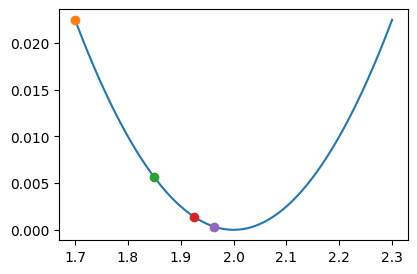

In [12]:
x = torch.linspace(1.7,2.3,100)
plt.plot(x,f(x))
#초기설정값
alpha = 1.00
x_sol = 1.7
plt.plot(x_sol, f(x_sol),'o')
# # 1회 update
slope = (1/2)*(x_sol-2)
x_sol = x_sol - alpha*slope
plt.plot(x_sol, f(x_sol),'o')
# 2회 update
slope = (1/2)*(x_sol-2)
x_sol = x_sol - alpha*slope
plt.plot(x_sol, f(x_sol),'o')
# 3회 update
slope = (1/2)*(x_sol-2)
x_sol = x_sol - alpha*slope
plt.plot(x_sol, f(x_sol),'o')

`-` 반복연산

In [13]:
alpha = 1.00
x_sol = 2.23
for dummy in range(30):
    slope = (1/2)*(x_sol-2)
    x_sol = x_sol - alpha*slope
x_sol

2.000000000214204

`-` 애니메이션

In [ ]:
#| code-fold: true
def make_ani(alpha=0.1, initial_value=2.23, n_iterations=5):
    """
    Gradient descent visualization

    Parameters:
    - alpha: learning rate
    - initial_value: initial x value (single number)
    - n_iterations: number of iterations
    """
    # Calculate trajectory
    x_sol_trace = [initial_value]
    slopes = []
    for i in range(n_iterations):
        slope = 1/2*(x_sol_trace[i]-2)
        slopes.append(slope)
        x_sol_trace.append(x_sol_trace[i] - alpha*slope)
    x_sol_trace = torch.tensor(x_sol_trace)
    y_trace = f(x_sol_trace)

    # Setup plot
    fig = plt.figure()
    ax = fig.gca()

    # Fixed x range
    x_min, x_max = 1.65, 2.35

    # Plot function curve
    x_range = torch.linspace(x_min, x_max, 100)
    ax.plot(x_range, f(x_range), 'k-', linewidth=1.5)
    ax.set_xlim([x_min, x_max])
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)

    # Initialize current point and previous points
    point, = ax.plot([], [], 'o', color='black', markersize=6)
    prev_points, = ax.plot([], [], 'o', color='gray', markersize=6, alpha=0.5)

    # Store arrows
    slope_arrows = []
    shift_arrows = []

    # Create legend handles (will be updated in animation)
    from matplotlib.patches import Patch, FancyArrowPatch
    slope_patch = Patch(color='red', label='slope: --')
    shift_patch = Patch(color='blue', label='shift: --')
    legend = ax.legend(handles=[slope_patch, shift_patch], loc='upper center', fontsize=9)

    def animate(frame):
        nonlocal slope_arrows, shift_arrows, legend

        # Remove all previous arrows
        for arrow in slope_arrows:
            arrow.remove()
        for arrow in shift_arrows:
            arrow.remove()

        slope_arrows = []
        shift_arrows = []

        idx = frame

        # Update current point position
        point.set_data([x_sol_trace[idx]], [y_trace[idx]])

        # Update previous points (all points before current)
        if idx > 0:
            prev_points.set_data(x_sol_trace[:idx], y_trace[:idx])
        else:
            prev_points.set_data([], [])

        if idx < len(slopes):
            current_x = x_sol_trace[idx].item()
            slope_val = slopes[idx]
            shift = - alpha * slope_val

            # Get y-axis limits for proper arrow sizing
            y_min, y_max = ax.get_ylim()
            y_range = y_max - y_min

            # Slope arrow: slightly above x-axis using FancyArrowPatch
            y_slope = y_min + y_range * 0.08
            slope_arrow = FancyArrowPatch((current_x, y_slope),
                                         (current_x + slope_val, y_slope),
                                         arrowstyle='->',
                                         color='red',
                                         lw=1.5,
                                         mutation_scale=12,
                                         zorder=5)
            ax.add_patch(slope_arrow)
            slope_arrows.append(slope_arrow)

            # Shift arrow: below slope arrow using FancyArrowPatch
            y_shift = y_min + y_range * 0.03
            shift_arrow = FancyArrowPatch((current_x, y_shift),
                                         (current_x + shift, y_shift),
                                         arrowstyle='->',
                                         color='blue',
                                         lw=1.5,
                                         mutation_scale=12,
                                         zorder=5)
            ax.add_patch(shift_arrow)
            shift_arrows.append(shift_arrow)

            # Update legend with current values
            legend.remove()
            slope_patch = Patch(color='red', label=f'slope: {slope_val:.4f}')
            shift_patch = Patch(color='blue', label=f'shift (-α×slope): {shift:.4f}')
            legend = ax.legend(handles=[slope_patch, shift_patch], loc='upper center', fontsize=9)

        return [point, prev_points]

    ani = matplotlib.animation.FuncAnimation(
        fig, animate, frames=n_iterations+1, blit=False, repeat=True
    )
    plt.tight_layout()
    plt.close()
    return ani

In [15]:
make_ani(alpha=4.1,initial_value=2.23) # alpha는 학습률 혹은 stepize 이라고 부름.

- alpha가 작을수록 천천히 최소값으로..
- alpha가 커지면 빠르게 최소값으로..
- alpha가 더 커지면 진동하면서 최소값으로 갈수도있음.
- alpha가 더 더 커지면 최소값으로 가지 못하고 진동만 할수도 있음.
- alpah가 더 더 더 커지면 진동하면서 발산하는 경우도 있음.

`(풀이5)`

`-` 풀이4의 비판: 솔직히 아래의 코드에서 `slope = (1/2)*(x_sol-2)` 를 칠 수 있는건 불가능할수도 있지 않나??

```Python
alpha = 1.00
x_sol = 2.23
for dummy in range(30):
    slope = (1/2)*(x_sol-2) # f'(x) = 1/2*(x-2)
    x_sol = x_sol - alpha*slope
x_sol
```

`-` `slope` 를 근사시키는 방식


$$f'(x_{sol}) \approx \frac{f(x_{sol}+h)-f(x_{sol})}{h}$$

In [16]:
def f(x):
    return (1/4)*(x-2)**2

In [17]:
alpha = 1.00
x_sol = 2.8
for dummy in range(30):
    slope = (f(x_sol + 0.01) - f(x_sol))/0.01
    x_sol = x_sol - alpha*slope
x_sol

1.9950000007497146

`#`

## B. 2차원

`# 예제2` -- d아래의 함수를 최소화하는 $(x,y)$값을 구하여라.

$$f(x,y)=(x-2)^2 + (y-3)^2$$



`(풀이)`

> $f(x,y)$는 아래로 볼록한 모양이라고 가정한다.

`-` 그래프를 확인해보자.

In [ ]:
#| code-fold: true
def plot_surface_3d(f, z_min=-500, z_max=500, x_range=None, y_range=None, n_points=800):
    # 최솟값/최대값 존재 여부 판단
    has_min, has_max = False, False

    # 최소 탐색
    p_min = torch.zeros(2, requires_grad=True)
    opt_min = torch.optim.Adam([p_min], lr=0.1)
    for _ in range(1000):
        opt_min.zero_grad()
        f(p_min[0], p_min[1]).backward()
        opt_min.step()
    # 수렴했으면 최솟값 존재 (발산 = 큰 좌표)
    if abs(p_min[0].item()) < 1e4 and abs(p_min[1].item()) < 1e4:
        has_min = True

    # 최대 탐색
    p_max = torch.zeros(2, requires_grad=True)
    opt_max = torch.optim.Adam([p_max], lr=0.1)
    for _ in range(1000):
        opt_max.zero_grad()
        (-f(p_max[0], p_max[1])).backward()
        opt_max.step()
    if abs(p_max[0].item()) < 1e4 and abs(p_max[1].item()) < 1e4:
        has_max = True

    if has_min or has_max:
        # 최소 또는 최대가 있으면 → 기존 적응적 탐색
        if has_min:
            cx, cy = p_min[0].item(), p_min[1].item()
        else:
            cx, cy = p_max[0].item(), p_max[1].item()

        n_search = 100
        half = 1.0
        max_half = 50.0
        for _ in range(20):
            if half > max_half:
                break
            x_s = torch.linspace(cx - half, cx + half, n_search)
            y_s = torch.linspace(cy - half, cy + half, n_search)
            Xs, Ys = torch.meshgrid(x_s, y_s, indexing='ij')
            Zs = torch.zeros(n_search, n_search)
            for i in range(n_search):
                for j in range(n_search):
                    Zs[i,j] = f(Xs[i,j], Ys[i,j])
            mask = (Zs > z_min) & (Zs < z_max)
            if not mask.any():
                half *= 2
                continue
            edge = mask[0,:].any() | mask[-1,:].any() | mask[:,0].any() | mask[:,-1].any()
            if not edge:
                break
            half *= 2

        x_in = Xs[mask]
        y_in = Ys[mask]
        margin_x = (x_in.max() - x_in.min()) * 0.1
        margin_y = (y_in.max() - y_in.min()) * 0.1
        x_lo, x_hi = x_in.min().item() - margin_x, x_in.max().item() + margin_x
        y_lo, y_hi = y_in.min().item() - margin_y, y_in.max().item() + margin_y

        # 주기성 감지
        def detect_period_1d(f_1d, t):
            d = f_1d[1:-1]
            minima = ((d < f_1d[:-2]) & (d < f_1d[2:])).nonzero().squeeze()
            if minima.dim() == 0 or minima.numel() < 2:
                return None
            dt = (t[1] - t[0]).item()
            diffs = (minima[1:] - minima[:-1]).float() * dt
            return diffs.median().item()

        n_period = 500
        scan_r = 20.0
        tx = torch.linspace(cx - scan_r, cx + scan_r, n_period)
        ty = torch.linspace(cy - scan_r, cy + scan_r, n_period)
        fx_slice = torch.tensor([f(tx[i], torch.tensor(cy)).item() for i in range(n_period)])
        fy_slice = torch.tensor([f(torch.tensor(cx), ty[i]).item() for i in range(n_period)])

        px = detect_period_1d(fx_slice, tx)
        py = detect_period_1d(fy_slice, ty)

        if px is not None:
            x_lo, x_hi = cx - px * 2, cx + px * 2
        if py is not None:
            y_lo, y_hi = cy - py * 2, cy + py * 2
    else:
        # 최소도 최대도 없으면 → 고정 범위
        x_lo, x_hi = -10, 10
        y_lo, y_hi = -10, 10

    # 수동 범위 지정 시 덮어쓰기
    if x_range is not None:
        x_lo, x_hi = x_range
    if y_range is not None:
        y_lo, y_hi = y_range

    # D 위에서 f 재계산
    x_vals = torch.linspace(x_lo, x_hi, n_points)
    y_vals = torch.linspace(y_lo, y_hi, n_points)
    X, Y = torch.meshgrid(x_vals, y_vals, indexing='ij')
    Z = torch.zeros(n_points, n_points)
    for i in range(n_points):
        for j in range(n_points):
            Z[i,j] = f(X[i,j], Y[i,j])

    # D 영역의 실제 z 범위로 재설정
    z_valid = Z[(Z >= z_min) & (Z <= z_max)]
    if z_valid.numel() > 0:
        z_min = z_valid.min().item()
        z_max = z_valid.max().item()

    # D 밖은 NaN → 안 그림
    Z_plot = Z.clone().float()
    Z_plot[(Z < z_min) | (Z > z_max)] = float('nan')

    z_margin = (z_max - z_min) * 0.05
    Xn, Yn, Zn = X.numpy(), Y.numpy(), Z_plot.numpy()

    fig = go.Figure(data=[go.Surface(
        x=Xn, y=Yn, z=Zn,
        colorscale='Viridis', opacity=0.9, showscale=False,
        contours={'z': {'show': True, 'usecolormap': True,
                        'project': {'z': True}}}
    )])

    fig.update_layout(
        scene=dict(
            xaxis=dict(title='x', backgroundcolor='rgba(230,230,230,1)',
                       gridcolor='rgba(80,80,80,0.2)', showbackground=True),
            yaxis=dict(title='y', backgroundcolor='rgba(230,230,230,1)',
                       gridcolor='rgba(80,80,80,0.2)', showbackground=True),
            zaxis=dict(title='z', backgroundcolor='rgba(230,230,230,1)',
                       gridcolor='rgba(80,80,80,0.2)', showbackground=True,
                       range=[z_min - z_margin, z_max + z_margin]),
            camera=dict(eye=dict(x=1.5, y=1.5, z=0.8)),
        ),
        width=750, height=750,
        margin=dict(l=0, r=0, t=0, b=0),
        paper_bgcolor='rgba(0,0,0,0)',
    )

    fig.show()

In [19]:
def f(x,y):
    return (x-2)**2 + (y-3)**2

In [20]:
#plot_surface_3d(f)

`-` 차원이 높아져서 당환스럽지만, 아래의 방식으로 알고리즘을 설계하면 최소값을 잘 찾을 것 같다.

1. 아무값이나 $x_{sol},y_{sol}$이라 주장한다.
2. 1에서 선택한 $(x_{sol},y_{sol})$근처의 값을 조사한다. 즉 아래의 값들을 조사한다.그리고 가장 $f(x,y)$를 작게만드는 값으로 update를 함.  
    - $(x_{sol},y_{sol}-0.1)$
    - $(x_{sol}-0.1,y_{sol}-0.1)$
    - $(x_{sol}+0.1,y_{sol}-0.1)$
    - $(x_{sol},y_{sol})$
    - $(x_{sol}-0.1,y_{sol})$
    - $(x_{sol}+0.1,y_{sol})$
    - $(x_{sol},y_{sol}+0.1)$
    - $(x_{sol}-0.1,y_{sol}+0.1)$
    - $(x_{sol}+0.1,y_{sol}+0.1)$
3. 2에서 업데이트된 $(x_{sol}',y_{sol}')$을 다시 1의 $(x_{sol},y_{sol})$로 해석하고 1-2를 반복한다.



`-` 위의 방식과 다르지만 아래의 방식도 가능할 것 같다.

1. 아무값이나 $x_{sol},y_{sol}$이라 주장한다.
2. 1에서 선택한 $(x_{sol},y_{sol})$에 대하여 다음을 수행한다.
    - $f(x_{sol}-0.1, y_{sol}), f(x_{sol},y_{sol}), f(x_{sol}+0.1,y_{sol})$를 비교하여 $x$의 이동방향을 결정한다.
    - $f(x_{sol}, y_{sol}-0.1), f(x_{sol},y_{sol}), f(x_{sol},y_{sol}+0.1)$를 비교하여 $y$의 이동방향을 결정한다.
    - 결정된 방향으로 동시에 이동하여 $x_{sol},y_{sol}$을 update한다.
3. 2에서 업데이트된 $(x_{sol}',y_{sol}')$을 다시 1의 $(x_{sol},y_{sol})$로 해석하고 1-2를 반복한다.

`-` 고차원일 경우?

|차원 $d$| 알고리즘1 | 알고리즘2 |
|:--:|:--:|:--:|
|2 | 9 | 5|
|3 | 27 | 7 |
|...| ... | ... |
| 10 | 59049 | 21|

`-` 첫번째 알고리즘이 더 좋아보이긴 하는데 계산량이 너무 많아 못쓰겠음. 두번쨰 알고리즘을 쓰자.

`-` `0.01`씩 항상 업데이트하는건 말이 되지 않으므로 최종알고리즘은 아래와 같이 다시 정리해야겠음.


`# 경사하강법 아이디어 (2차원) -- 근사`

1. 임의의 점 $(x_{sol},y_{sol})$을 찍는다.
2. 그 점에서 그래디언트를 구한다. (= 그 점에서 편미분계수를 구한다) 그래디언트의 반대방향으로 이동하며 이동폭은 $\alpha$로 조정한다. 따라서 업데이트하는 수식은 아래와 같다.
$$[x_{sol},y_{sol}]
 \leftarrow \left[x_{sol} - \alpha \times \frac{f(x_{sol}+h,y_{sol})-f(x_{sol},y_{sol})}{h},y_{sol} - \alpha \times \frac{f(x_{sol},y_{sol}+h)-f(x_{sol},y_{sol})}{h}\right]$$
3. 반복한다.



`#`

![.](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d2/3d-gradient-cos.svg/960px-3d-gradient-cos.svg.png)

- 참고할만한 그림: $\alpha=1.0$이라면 각 점에서 화살표방향의 정확히 반대로 움직일 것이다. (ref: <https://en.wikipedia.org/wiki/Gradient>)

`-` 컬럼벡터를 이용하여 위으 수식을 간단히 표현하면 아래와 같다.

`# 경사하강법 아이디어 (2차원) -- 근사`

1. 임의의 점 $(x_{sol},y_{sol})$을 찍는다.
2. 그 점에서 그래디언트를 구한다. (= 그 점에서 편미분계수를 구한다) 그래디언트의 반대방향으로 이동하며 이동폭은 $\alpha$로 조정한다. 따라서 업데이트하는 수식은 아래와 같다.
$$\begin{bmatrix}x_{sol} \\ y_{sol}\end{bmatrix} \leftarrow \begin{bmatrix}x_{sol} - \alpha \times \frac{f(x_{sol}+h,y_{sol})-f(x_{sol},y_{sol})}{h} \\ y_{sol} - \alpha \times \frac{f(x_{sol},y_{sol}+h)-f(x_{sol},y_{sol})}{h}\end{bmatrix}$$
3. 반복한다.

`#`

`-` 그래디언트를 이용하여 더 간결하게 표현하면 아래와 같다.

`# 경사하강법 아이디어 (2차원)`

1. 임의의 점 $(x_{sol},y_{sol})$을 찍는다.
2. 그 점에서 그래디언트를 구한다. (= 그 점에서 편미분계수를 구한다) 그래디언트의 반대방향으로 이동하며 이동폭은 $\alpha$로 조정한다. 따라서 업데이트하는 수식은 아래와 같다.
$$\begin{bmatrix}x_{sol} \\ y_{sol}\end{bmatrix} \leftarrow \begin{bmatrix}x_{sol}  \\ y_{sol} \end{bmatrix} - \alpha \times \nabla f(x_{sol},y_{sol})$$
3. 반복한다.

`#`

`-` 풀어보자.

In [21]:
def f(x,y):
    return (x-2)**2 + (y-3)**2

In [22]:
x_sol = 5
y_sol = 5
alpha = 0.1

In [23]:
for dummy in range(5):
    x_grad = (f(x_sol+0.01, y_sol) - f(x_sol,y_sol))/0.01
    y_grad = (f(x_sol, y_sol+0.01) - f(x_sol,y_sol))/0.01
    x_sol = x_sol - alpha * x_grad
    y_sol = y_sol - alpha * y_grad
    print(x_sol, y_sol)

4.399000000000015 4.599000000000011
3.9182000000000095 4.278200000000005
3.5335600000000156 4.021560000000015
3.225848000000018 3.816248000000013
2.979678400000023 3.651998400000016


`-` 위의 알고리즘은 아래의 알고리즘과 다름을 주의하자.

`# 경사하강법 아님`

1. 임의의 점 $(x_{sol},y_{sol})$을 찍는다.
2. 아래의 수식으로 업데이트한다.
- $x_{sol}  \leftarrow x_{sol} - \alpha \times \frac{f(x_{sol}+h,y_{sol})-f(x_{sol},y_{sol})}{h}$
- $y_{sol}  \leftarrow y_{sol} - \alpha \times \frac{f(x_{sol},y_{sol}+h)-f(x_{sol},y_{sol})}{h}$
3. 반복한다.

`#`

위의 알고리즘에 대응하는 코드는 아래와 같음


```Python
for dummy in range(5):
    x_grad = (f(x_sol+0.01, y_sol) - f(x_sol,y_sol))/0.01
    x_sol = x_sol - alpha * x_grad
    y_grad = (f(x_sol, y_sol+0.01) - f(x_sol,y_sol))/0.01
    y_sol = y_sol - alpha * y_grad
    print(x_sol, y_sol)
```

# 4. 회귀분석

## A. 아이스아메리카노

`-` 카페주인 박혜원씨는 온도와 아이스아메리카노 판매량이 관계가 있다는 사실을 알았음. 구체적으로는

> "온도가 높아질수록 (=날씨가 더울수록) 아이스아메리카노 판매량이 증가"

한다는 사실을 알게되었다.

In [24]:
temp = [-2.4821, -2.3621, -1.9973, -1.6239, -1.4792, -1.4635, -1.4509, -1.4435,
        -1.3722, -1.3079, -1.1904, -1.1092, -1.1054, -1.0875, -0.9469, -0.9319,
        -0.8643, -0.7858, -0.7549, -0.7421, -0.6948, -0.6103, -0.5830, -0.5621,
        -0.5506, -0.5058, -0.4806, -0.4738, -0.4710, -0.4676, -0.3874, -0.3719,
        -0.3688, -0.3159, -0.2775, -0.2772, -0.2734, -0.2721, -0.2668, -0.2155,
        -0.2000, -0.1816, -0.1708, -0.1565, -0.1448, -0.1361, -0.1057, -0.0603,
        -0.0559, -0.0214,  0.0655,  0.0684,  0.1195,  0.1420,  0.1521,  0.1568,
         0.2646,  0.2656,  0.3157,  0.3220,  0.3461,  0.3984,  0.4190,  0.5443,
         0.5579,  0.5913,  0.6148,  0.6469,  0.6469,  0.6523,  0.6674,  0.7059,
         0.7141,  0.7822,  0.8154,  0.8668,  0.9291,  0.9804,  0.9853,  0.9941,
         1.0376,  1.0393,  1.0697,  1.1024,  1.1126,  1.1532,  1.2289,  1.3403,
         1.3494,  1.4279,  1.4994,  1.5031,  1.5437,  1.6789,  2.0832,  2.2444,
         2.3935,  2.6056,  2.6057,  2.6632]

In [25]:
sales= [-8.5420, -6.5767, -5.9496, -4.4794, -4.2516, -3.1326, -4.0239, -4.1862,
        -3.3403, -2.2027, -2.0262, -2.5619, -1.3353, -2.0466, -0.4664, -1.3513,
        -1.6472, -0.1089, -0.3071, -0.6299, -0.0438,  0.4163,  0.4166, -0.0943,
         0.2662,  0.4591,  0.8905,  0.8998,  0.6314,  1.3845,  0.8085,  1.2594,
         1.1211,  1.9232,  1.0619,  1.3552,  2.1161,  1.1437,  1.6245,  1.7639,
         1.6022,  1.7465,  0.9830,  1.7824,  2.1116,  2.8621,  2.1165,  1.5226,
         2.5572,  2.8361,  3.3956,  2.0679,  2.8140,  3.4852,  3.6059,  2.5966,
         2.8854,  3.9173,  3.6527,  4.1029,  4.3125,  3.4026,  3.2180,  4.5686,
         4.3772,  4.3075,  4.4895,  4.4827,  5.3170,  5.4987,  5.4632,  6.0328,
         5.2842,  5.0539,  5.4538,  6.0337,  5.7250,  5.7587,  6.2020,  6.5992,
         6.4621,  6.5140,  6.6846,  7.3497,  8.0909,  7.0794,  6.8667,  7.4229,
         7.2544,  7.1967,  9.5006,  9.0339,  7.4887,  9.0759, 11.0946, 10.3260,
        12.2665, 13.0983, 12.5468, 13.8340]

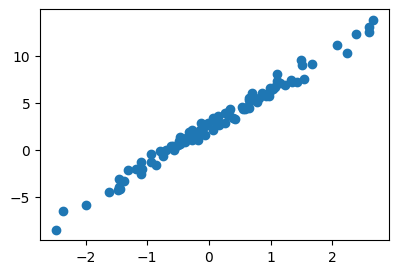

In [26]:
plt.plot(temp,sales,'o')

오늘 바깥의 온도가 0.5이다. 아이스아메리카노를 몇잔정도 만들어 두면 좋을까?

## B. A의 자료를 만든 방법 (박혜원씨는 이걸 모름)

`-` 아래의 모형에서 $y_i = \text{sales}_i$, $x_i = \text{temp}_i$ 라고 생각하고 만들었음.

$$y_i = 2.5 + 4 x_i + \epsilon_i, i=1,2,\dots,n$$

In [27]:
torch.manual_seed(43052)
x = torch.randn(100).sort()[0]
eps = torch.randn(100)*0.5
y = 4*x + 2.5 + eps

`-` 시각화

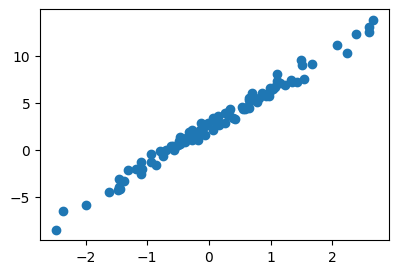

In [28]:
plt.plot(x,y,'o')
#plt.plot(x,4*x + 2.5,'--')

- 최규빈이 보는 그림과
- 박혜원씨가 보는 그림은 다르다.

## C. 다시 박혜원씨의 세상으로

`-` 데이터를 다시 관찰하자.

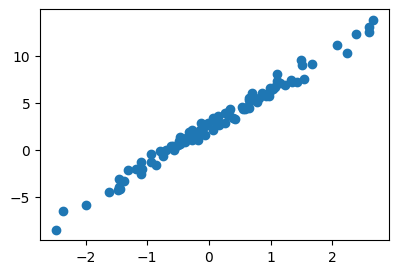

In [29]:
plt.plot(temp,sales,'o')

`-` 박혜원씨의 의심: 이 세상이 혹시 시뮬레이션 아니야???

- 내가 관측한 `sales`가 $\text{sales}_i = \beta_0 + \beta_1 \text{temp}_{i} + \epsilon_i, \epsilon_i \sim \overset{i.i.d}{\sim} N(0,1)$ 에서 얻어진 것 같아..
- 증거?? 그냥 느낌이 그래.. (그림을 딱보니까 그냥 느낌이 그래) <--- 검증이 필요함 (잔차분석)

`-` 박혜원씨의 생각: 앞으로 이 세상은 시뮬레이션이라고 가정하자.

- 본질적으로 `sales`하고 `temp`사이에는 직선의 관계가 있어야 한다. ($x_i,y_i$가 선형성을 가짐)
- 그런데 왜 그림을 그려보면 "정확한"직선으로 보이지 않냐??? 누군가가 각 관측치에 장난질을 쳐서 본질을 흐리고 있기 때문이다.
- 나는 장난질에 흔들리지 않고 본질을 꿰뚫어 보겠다. (즉 파란점들을 적당히 잘 관통하는 직선을 찾겠다) 그래서 커피판매량을 잘 예측해서 부자가 되는 것이 목표이다.

`-` 본질을 꿰뚫어 봄 = $(x_i, y_i)$를 "적당히 잘 관통하는 하나의 추세선"을 그리는 것 = 최~~~~대한 $y_i \approx \beta_0 + \beta_1 x_i$ 를 만족하도록 $\beta_0,\beta_1$을 잘 선택하는 것.

`# 박혜원씨의 시도1` -- 혹시.. $[\beta_0, \beta_1] = [-5, 10]$ 아니야??

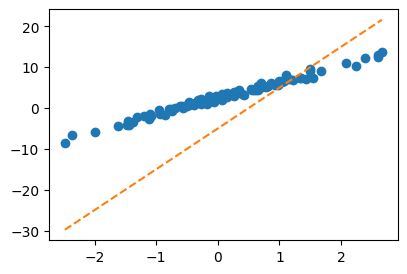

In [30]:
plt.plot(x,y,'o')
plt.plot(x,-5+10*x, '--')

- 박혜원씨의 생각: 이게 아니네..
- 우리의 생각: 그래 그거 아니야.. 사실 진짜값은 $[\beta_0,\beta_1] = [2.5, 4]$ 이거든!!

`#`

`# 박혜원씨의 시도2` -- 혹시.. $[\beta_0, \beta_1] = [2.5, 3.5]$ 아니야??

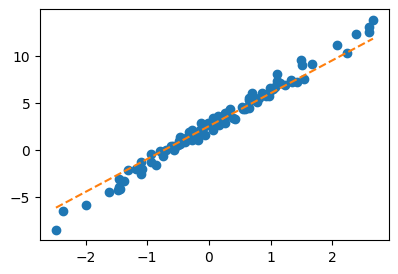

In [31]:
plt.plot(x,y,'o')
plt.plot(x,2.5+3.5*x, '--')

- 박혜원씨의 생각: 이거는 첫번째 보다 상당히 그럴듯한데??
- 우리의 생각: 와 맞아.. 거의 다 왔어.. 더 힘내.. 사실 진짜값은 $[\beta_0,\beta_1] = [2.5, 4]$ 이거든!!

`#`

`# 박혜원씨의 시도3` -- 혹시.. $[\beta_0, \beta_1] = [2.3, 3.5]$ 아니야??

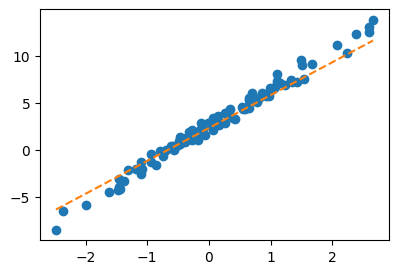

In [32]:
plt.plot(x,y,'o')
plt.plot(x,2.3+3.5*x, '--')

- 박혜원씨의 생각: 이게 더 그럴듯한가?? 아니면 아까 그게 더 그럴듯한가??
- 우리의 생각: 아니야.. 아까것이 더 좋은가야.. 사실 진짜값은 $[\beta_0,\beta_1] = [2.5, 4]$ 이거든!!

`#`

`-` 솔직히 박혜원씨 입장에서는 시도2랑 시도3중에 뭐가 더 "적당한 직선"인지 구분하는게 어렵지 않나?? $\to$ "적당함"을 수식화할 필요가 있겠다.

`-` "적당한 정도"를 판단하는 장치: loss의 개념 도입

$$loss =\sum_{i=1}^{n}\big(y_i -(\beta_0 + \beta_1x_i)\big)^2$$

> 회귀분석에서는 위 수식을 SSE라고 하죠

- 여기에서 $y_i$는 파란색을 의미
- 또한 $\beta_0 + \beta_1 x_i$는 주황색을 의미
- loss는 모든 $i$에 대하여 대체로 $y_i \approx \beta_0 + \beta_1 x_i$일수록 그 값이 작아짐..
- loss는 주황색이 대체로 파란색과 비슷해질수록 그 값이 작음.

`-` loss를 써먹어보자.

In [33]:
# 시도2
b0 = 2.5
b1 = 3.5
loss = torch.sum((y-(b0 + b1*x))**2)
print(loss)

tensor(55.0740)


In [34]:
# 시도3
b0 = 2.3
b1 = 3.5
loss = torch.sum((y-(b0 + b1*x))**2)
print(loss)

tensor(59.3805)


- 박혜원씨 생각: 아... 시도2가 더 좋았구나..
- 우리의 생각: 그래 맞아~~ 시도2가 더 좋다니까?? (진짜 값이 $[\beta_0,beta_1] = [2.5, 4]$ 이거든)

`-` 정리

1. 박혜원씨 관점에서는 온도를 알면 커피판매량을 잘 예측하고 싶음.
2. 1을 위해서는 최대한 $y_i \approx \beta_0 + \beta_1 x_i$이 되도록 하는 $\beta_0, \beta_1$을 찾아야함.
3. 2를 위해서는 $loss$를 가장 작게 만드는 $\beta_0,\beta_1$의 값을 찾으면 됨.

> 그런데 결국 loss는 $\beta_0,\beta_1$의 값을 입력으로 주면 출력으로 하나의 값을 주는 함수라고 볼 수 있음.

`-` 결국 정리하면 $f(x,y)$를 최소로 만드는 $x,y$를 찾는 최적화문제와 동일하게 된다. (그런데 우리는 이런걸 잘해요)

In [35]:
def l(b0,b1):
    return torch.sum((y-(b0 + b1*x))**2)

In [36]:
# plot_surface_3d(l) # -- 그림을 그려보니까 "아래로 볼록하네?"

In [37]:
b0 = -5
b1 = 10

In [38]:
alpha = 0.001
b0_grad = (l(b0+0.001,b1) - l(b0,b1))/0.001
b1_grad = (l(b0,b1+0.001) - l(b0,b1))/0.001
b0 = b0 - alpha * b0_grad
b1 = b1 - alpha * b1_grad

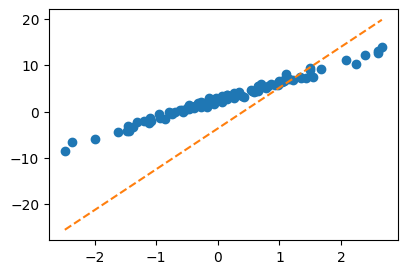

In [39]:
plt.plot(x,y,'o')
plt.plot(x,b0+b1*x,'--')

`-` 수렴과정확인

In [ ]:
#| code-fold: true
plt.rcParams['figure.figsize'] = (7.5,2.5)
plt.rcParams["animation.html"] = "jshtml"
def make_ani2(alpha=0.001):
    ## 1. 히스토리 기록을 위한 list 초기화
    loss_history = []
    yhat_history = []
    b0_history = []
    b1_history = []

    ## 2. 학습 + 학습과정기록
    b0 = -5.0
    b1 = 10.0
    b0_history.append(b0)
    b1_history.append(b1)
    for epoc in range(30):
        yhat = b0 + b1*x
        yhat_history.append(yhat.tolist())
        loss = torch.sum((y - yhat)**2)
        loss_history.append(loss.item())
        b0_grad = (l(b0+0.01, b1) - l(b0, b1)) / 0.01
        b1_grad = (l(b0, b1+0.01) - l(b0, b1)) / 0.01
        b0 = b0 - alpha * b0_grad
        b1 = b1 - alpha * b1_grad
        b0_history.append(b0)
        b1_history.append(b1)

    ## 3. 시각화
    fig = plt.figure()
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')

    #### ax1: yhat의 관점에서..
    ax1.plot(x, y, 'o')
    line, = ax1.plot(x, yhat_history[0])

    #### ax2: loss의 관점에서..
    import numpy as np
    w0 = np.arange(-6, 11, 0.5)
    w1 = np.arange(-6, 11, 0.5)
    W1, W0 = np.meshgrid(w1, w0)
    LOSS = W0 * 0
    for i in range(len(w0)):
        for j in range(len(w1)):
            LOSS[i,j] = torch.sum((y - w0[i] - w1[j]*x)**2)
    ax2.plot_surface(W0, W1, LOSS, rstride=1, cstride=1, color='k', alpha=0.1)
    ax2.azim = 30
    ax2.dist = 8
    ax2.elev = 5
    ax2.set_xlabel(r'$\beta_0$')
    ax2.set_ylabel(r'$\beta_1$')
    ax2.set_xticks([-5, 0, 5, 10])
    ax2.set_yticks([-5, 0, 5, 10])
    ax2.scatter(-5, 10, l(-5, 10), s=200, marker='*', color='C1')

    def animate(epoc):
        line.set_ydata(yhat_history[epoc])
        ax2.scatter(b0_history[epoc], b1_history[epoc], loss_history[epoc], color='C1',alpha=0.5)
        fig.suptitle(f'alpha = {alpha} / epoch = {epoc}')
        return [line]

    ani = matplotlib.animation.FuncAnimation(
        fig, animate, frames=30, blit=False, repeat=True
    )
    plt.close()
    return ani

In [41]:
make_ani2(0.003)